# Toy EBM Notebook

This notebook mirrors the sections in `toyEBM.py` so each part can be run independently.

In [1]:
import torch
import torch.nn as nn 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

## 1. Make the universe and visualize the points

3.5354629803157067 -1.0873360535694583
4.500422630139685 -2.732291975002653
4.995979141456019 -2.6754842931406433
4.112796108300643 -1.239878763775926
4.022757339759153 0.43259104095855117
8.274443777674293 3.3043347355218677
9.267133327425935 1.5086808313169158
9.827813699851848 0.19422062065612478
9.921464347001695 2.071009683207694
10.098970485576796 1.2092614162078852
9.291779244186731 -0.560749917617271
8.656136121297354 -1.8049953375432624
6.252223318769609 -0.778513307222799
7.665522823180311 -0.7948755212164609
8.310301981266264 3.11785137898604
9.609423348374946 1.2011877760288563
10.184481804105644 2.188655100272711
3.5113639504949106 -0.01899829390365193
4.9599479257975645 -3.4086783590255973
5.575291862597965 0.36507214811480093
5.113815569138296 -3.242030708036515
5.042277522383188 -2.9011299267861212
-7.709596667407623 1.489662039211216
-7.583734073036708 2.2462087713284338
6.786535035030624 -2.3822759127436157
6.049771603289855 2.7872385116055156
-8.736156844550361 -1.78

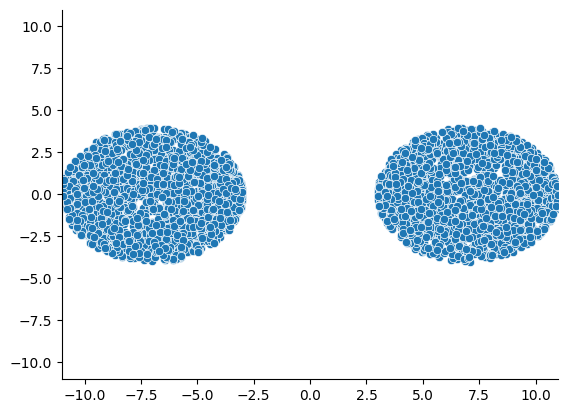

In [2]:
# Making The universe
x_1 = np.random.uniform(3,11,2000)
x_2 = np.random.uniform(-3,-11,2000)
x = set(x_1).union(set(x_2))
x = np.array(list(x))
x_train_pts = []
max_y = -torch.inf
min_y = torch.inf
max_x = max(x)
min_x = min(x)
for val in x:
    if val < 0:
        y = np.random.uniform(-np.sqrt(16-(val+7)**2),np.sqrt(16-(val+7)**2),1)
    else:
        y = np.random.uniform(-np.sqrt(16-(val-7)**2),np.sqrt(16-(val-7)**2),1)
    x_train_pts.append((val, y[0]))
    print(val, y[0])
    max_y = max(max_y, y[0])
    min_y = min(min_y, y[0])

y_real = np.ones(len(x_train_pts))
# Visualize the data 
ax = sns.scatterplot(x=[i[0] for i in x_train_pts], y=[i[1] for i in x_train_pts])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

ax.set_ylim(-11, 11)
ax.set_xlim(-11, 11)

plt.show()

#Converting to Tensors
x_train_pts = torch.tensor(x_train_pts, dtype=torch.float32)

## 2. Generate fake points and build the training split

In [3]:
'''
As this is a very simple problem with distinct clusters, we can generate easy fakes by using a mix of perturbation and random sampling. This will likely not work for more intricate datasets.
TODO: Experiment with more advanced fake generation techniques (Adversarial Sampling LeCun, or MCMC sampling)
'''
length = len(x_train_pts)
print(length)
#Perturbation sampling
x_fake = (torch.randn_like(x_train_pts[:int(length*0.8)]) * 0.001) + x_train_pts[:int(length*0.8)]
#Random Sampling
temp = torch.rand(round(length - length*0.8)) * (max_x - min_x) + min_x
temp = torch.stack((temp, torch.rand_like(temp) * (max_y - min_y) + min_y), dim=1)
x_fake = torch.cat((x_fake, temp), dim=0)
y_fake = np.zeros(len(x_fake))

#Create Training Loop
#TODO: Concat real and fake data
x_dataset = torch.cat((x_train_pts, x_fake), dim=0)
y_dataset = np.concatenate((y_real, y_fake))
y_dataset = torch.tensor(y_dataset, dtype=torch.float32)

x_train, x_test, y_train, y_test = train_test_split(x_dataset, y_dataset, test_size=.20, random_state=42)

4000


## 3. Define the model, loss, and training loop

tensor([0.8045, 0.7469, 0.8316, 0.8090, 0.8190, 0.7638, 0.8023, 0.8273, 0.8111,
        0.8009, 0.8084, 0.8215, 0.7671, 0.7578, 0.7745, 0.7716, 0.7586, 0.8243,
        0.7976, 0.8243, 0.7545, 0.7934, 0.7503, 0.7722, 0.7706, 0.7757, 0.7945,
        0.8272, 0.7655, 0.8288, 0.7945, 0.7494, 0.7823, 0.7462, 0.7634, 0.7469],
       grad_fn=<SqueezeBackward0>)
Epoch 0, batch 0, loss 16.582380294799805 

tensor([104.8774, 508.7685, 508.1982, 596.2828, 123.0148, 400.5345, 202.3451,
        197.0059, 542.8923, 217.3216, 344.8692, 250.6655, 234.1691, 252.2447,
        184.5657, 194.8004, 553.3055, 390.4486, 522.6815, 364.3356, 132.6364,
        622.8537, 177.4478, 185.0896, 205.5221, 571.5113, 192.8581, 309.1225,
        302.8802, 692.3491, 572.3210, 363.6628, 258.1989, 714.1963, 384.1110,
        185.9597], grad_fn=<SqueezeBackward0>)
Epoch 0, batch 9, loss 208.6700897216797 

tensor([  0.7709,  25.0896,  68.5205,  59.9741,  92.7386,  64.6213, 103.4856,
         51.6660,   4.3191,  99.5880,  23.

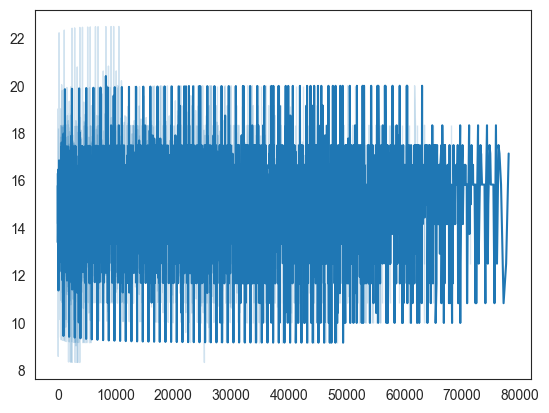

In [ ]:
#TODO: Forward pass through MLP, use Contrastive Margin Loss, if the flag is real, pred energy - 0 pull down
class MultiLaterPerceptron(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MultiLaterPerceptron, self).__init__()

        # Layer 1
        self.fc1 = nn.Linear(input_size, hidden_size)
        # Layer 2
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        # Layer 3
        self.fc3 = nn.Linear(hidden_size, hidden_size // 2)
        # Out Layer
        self.fc4 = nn.Linear(hidden_size // 2, output_size)
        # ReLU Activation 
        self.softplus = nn.Softplus()
    def forward(self, x):
        out = self.fc1(x)
        out = self.softplus(out)
        out = self.fc2(out)
        out = self.softplus(out)
        out = self.fc3(out)
        out = self.softplus(out)
        out = self.fc4(out)
        out = self.softplus(out)
        return out


#TODO: if the flag is fake, check if pred energy is below m, if energy is higher than m, penalty is 0, else push up
#BUILD Contrastive Margin Loss

def ContrastiveMarginLoss(Y, margin, pred):
    L_margin_M = (Y * pred) + ((1 - Y) * torch.relu(margin - pred))
    Loss = torch.mean(L_margin_M)
    return Loss
#TODO: Backprop
loss_data = []
x = []
batch_size = 36
epochs = 50
model = MultiLaterPerceptron(2, 128, 1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
for epoch in range(epochs):
    i = 0
    # Set model to training mode 
    model.train()
    while i < len(x_train):
        X, y = x_train[i:i+batch_size], y_train[i:i+batch_size]
        optimizer.zero_grad()
        outputs = model(X).squeeze()
        print(outputs)
        loss = ContrastiveMarginLoss(y, 30, outputs)
        print(f'Epoch {epoch}, batch {i//4}, loss {loss.item()} \n')
        x.append(epoch * (i//4))
        loss_data.append(loss.item())
        loss.backward()
        optimizer.step()
        i += batch_size 

sns.lineplot(x=x, y=loss_data)
plt.show()

In [ ]:
# Hyperparameter Tuning 



## 4. Build the energy heatmap

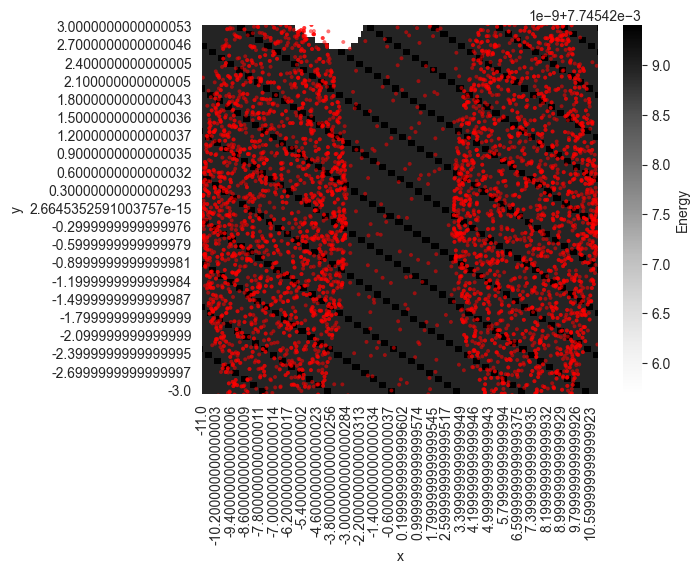

In [19]:
# Heatmap of energy 
gap = 0.1

x = np.arange(min_x, max_x  + gap, gap)
y = np.arange(min_y, max_y + gap, gap)

xx, yy = np.meshgrid(x, y)
points = np.column_stack([xx.ravel(), yy.ravel()])

points_val = [tuple(p) for p in points]

points = torch.tensor(points_val, dtype=torch.float32)

model.eval()
y_values = []

with torch.no_grad():
    i = 0
    while i < len(points):
        X_eval = points[i:i+batch_size]
        out_eval = model(X_eval).squeeze()
        y_values.append(out_eval)
        i += batch_size


points_val = pd.DataFrame(data=points_val, columns=['x','y'])
energy_val = torch.cat(y_values).cpu().numpy()
plot_data = points_val.copy()
plot_data['out'] = energy_val
heatmap_data = plot_data.pivot(index='y', columns='x', values='out').sort_index(ascending=False)
sns.set_style('white')
ax = sns.heatmap(heatmap_data, cmap='Greys', cbar_kws={'label': 'Energy'})

x_train_overlay = x_train.detach().cpu().numpy()
ax.scatter(
    (x_train_overlay[:, 0] - min_x) / gap + 0.5,
    (x_train_overlay[:, 1] - min_y) / gap + 0.5,
    s=8,
    c='red',
    alpha=0.55,
    edgecolors='none',
)

ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

## 5. Ideal energy function helper

In [ ]:
#Ideal Energy Function

def energy_function(a, b, x_train_pts, max_x, min_x, max_y, min_y):
    centroid = ((max_x + min_x) / 2, (max_y + min_y) / 2)
    angle = np.arctan2(centroid[1] - b, centroid[0] - a)
    distance = np.sqrt((centroid[0] - a) ** 2 + (centroid[1] - b) ** 2)

    circle_radius = distance
    sweep = 1
    found = False
    # TODO: Implement the algorithm to sweep (the circle_radius) near the angle of the line connecting the centroid and the point (a,b) and if it finds a point in the data within that sweep. It should brute force calculate the minimum distance from a,b to any point in the data and store that min point.
    # TODO: Then it should make the circle_radius the length of the line connecting a,b to that min point and have the centriod be (a,b). It should then sweep the entire 360 degrees to find the minimum distance from a,b to any point in the data and return that minimum distance as the energy.
    # TODO: In the case it doesnt find any point within the full 360 degree sweep, it should keep increasing the circle_radius until it finds a point in the data and then perform the same algorithm as above.
    # Finished TODOS above 
    while sweep <= 360:
        half_sweep = np.radians(sweep) / 2
        for point in x_train_pts:
            px, py = point[0], point[1]
            pt_dist = np.sqrt((px - a) ** 2 + (py - b) ** 2)
            pt_angle = np.arctan2(py - b, px - a)
            angle_diff = abs(pt_angle - angle) % (2 * np.pi)
            angle_diff = min(angle_diff, 2 * np.pi - angle_diff)
            if pt_dist <= circle_radius and angle_diff <= half_sweep:
                found = True
                break
        if found:
            break
        sweep += 1

    if not found:
        while not found:
            circle_radius *= 1.1
            for point in x_train_pts:
                px, py = point[0], point[1]
                pt_dist = np.sqrt((px - a) ** 2 + (py - b) ** 2)
                if pt_dist <= circle_radius:
                    found = True
                    break

    min_dist = np.inf
    min_point = None
    for point in x_train_pts:
        px, py = point[0], point[1]
        d = np.sqrt((px - a) ** 2 + (py - b) ** 2)
        if d < min_dist:
            min_dist = d
            min_point = point

    circle_radius = min_dist
    energy = np.inf
    for point in x_train_pts:
        px, py = point[0], point[1]
        d = np.sqrt((px - a) ** 2 + (py - b) ** 2)
        if d <= circle_radius and d < energy:
            energy = d

    return energy